# Bethel's Algorithm in Python

Python port of the CRAN package [`bethel`](https://cran.r-project.org/package=bethel) (author: Michele De Meo).

The **Bethel (1989)** procedure computes **total sample size** and **stratum allocation** for **multivariate stratified surveys**, minimizing cost subject to precision constraints expressed as **coefficients of variation (CV)** on total estimates.

**References:**
- Bethel, J.W. (1989). *Sample Allocation in Multivariate Surveys*. Survey Methodology, 15, 47–57.
- Chromy, J.B. (1987). *Design Optimization With Multiple Objectives*. ASA Survey Research Methods, 194–199.

## Background

Suppose we want to estimate **several variables** (e.g. total income, books read, sport days) in a population split into **strata** (e.g. sex × geographic area).

For each variable we set a target precision level (CV). Bethel's algorithm answers:

> *How many units should we sample in each stratum, at minimum cost, while meeting all precision constraints?*

The Python package exposes:

| Function | Role |
|---|---|
| `bth(strata, targets)` | Core algorithm (equivalent to R `bth()`) |
| `prepare_strata(...)` | Build the `strata` dataframe from unit-level data |
| `prepare_targets(...)` | Build the `targets` dataframe (CV + totals) |
| `load_pop()` | Example population (1000 individuals) |

## Installation

From the repository root:

```bash
pip install -e .
# optional, for the plot in this notebook:
pip install -e ".[notebook]"
```

Then import the main functions:

In [14]:
from bethel import bth, load_pop, prepare_strata, prepare_targets

import pandas as pd

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

## Example data: `pop`

The `pop` dataset contains **1000 individuals** classified by **sex** (M/F) and **geographic area** (area1–area4). For each unit:

- `income` — yearly income
- `books` — number of books read
- `sportDays` — total days of sporting activities

In [15]:
pop = load_pop()
pop.head(10)

,strata,income,books,sportDays
0,M_area1,27985.0,10.0,98.0
1,M_area1,7398.0,21.0,28.0
2,M_area1,44608.0,20.0,121.0
3,M_area1,13107.0,9.0,0.0
4,M_area1,30573.0,25.0,0.0
5,M_area1,17547.0,16.0,100.0
6,M_area1,25941.0,6.0,0.0
7,M_area1,25256.0,15.0,0.0
8,M_area1,39031.0,6.0,0.0
9,M_area1,27757.0,2.0,0.0


In [16]:
print(f"Observations: {len(pop):,}")
print(f"Strata: {pop['strata'].nunique()}")
pop.groupby("strata", observed=True).size().to_frame("N")

Observations: 1,000
Strata: 8


,N
strata,
F_area1,158
F_area2,120
F_area3,126
F_area4,40
M_area1,124
M_area2,180
M_area3,197
M_area4,55


## Algorithm inputs

The algorithm requires two dataframes, **`strata`** and **`targets`**, with explicit column names.

### Dataframe `strata`

| Column | Content |
|---|---|
| `strata` | Stratum label |
| `var_*` | Estimated variances of the target variables |
| `population_size` | Population size `N` in the stratum |
| `cost` | Unit cost per interview (often 1) |
| `min_sample` | Absolute minimum sample size (e.g. 3) |
| `min_rate` | Minimum sampling rate `n/N` (e.g. 0.04 = 4%) |

### Dataframe `targets` (one row per variable)

| Column | Content |
|---|---|
| `cv` | Target coefficient of variation |
| `total` | Estimated population total for the variable |

## Example 1 — Uniform CV (0.05)

This section reproduces the **CRAN R package example** from `help(bth)`:

- dataset `pop` (1000 units, 8 strata)
- variables `income`, `books`, `sportDays`
- `cost = 1`, `min_sample = 3`, `min_rate = 0.04`
- **CV = 0.05** for all variables

Expected total sample size: **162** (same as R `bth(b1, b2)`).

We use `prepare_strata` and `prepare_targets`, equivalent to the `tapply()` and `colSums()` steps in the R help page.

In [17]:
from IPython.display import display

var_cols = ["income", "books", "sportDays"]

strata = prepare_strata(
    pop,
    strata_col="strata",
    var_cols=var_cols,
    cost=1,         # same cost in all strata
    min_sample=3,   # at least 3 units per stratum
    min_rate=0.04,  # at least 4% of the stratum population
)

targets = prepare_targets(pop, var_cols, cv=0.05)

print("Strata — stratum-level inputs:")
display(strata)

print("\nTargets — precision constraints and totals:")
display(targets)

Strata — stratum-level inputs:


,strata,var_income,var_books,var_sportDays,population_size,cost,min_sample,min_rate
0,F_area1,1.732883e+08,50.439128,1471.367734,158,1.0,3.0,0.04
1,F_area2,1.469023e+08,43.873319,1756.310294,120,1.0,3.0,0.04
2,F_area3,1.645715e+08,60.549651,1313.439746,126,1.0,3.0,0.04
3,F_area4,1.614854e+08,74.742949,1636.025000,40,1.0,3.0,0.04
4,M_area1,1.841919e+08,52.517703,1661.695974,124,1.0,3.0,0.04
5,M_area2,1.666571e+08,50.421943,1493.444413,180,1.0,3.0,0.04
6,M_area3,1.598161e+08,49.926759,1290.623381,197,1.0,3.0,0.04
7,M_area4,1.860479e+08,57.839731,1596.331987,55,1.0,3.0,0.04



Targets — precision constraints and totals:


,cv,total
0,0.05,27509070.0
1,0.05,12429.0
2,0.05,56122.0


In [18]:
result = bth(strata, targets)
result

,strata,bethel_sample,adjusted_sample
0,F_area1,25,25
1,F_area2,21,21
2,F_area3,19,19
3,F_area4,7,7
4,M_area1,21,21
5,M_area2,29,29
6,M_area3,30,30
7,M_area4,10,10


In [19]:
summary = result.copy()
summary["population_size"] = strata["population_size"].to_numpy()
summary["pct"] = (summary["adjusted_sample"] / summary["population_size"] * 100).round(1)

print(f"Total sample size: {summary['adjusted_sample'].sum()}")
summary

Total sample size: 162


,strata,bethel_sample,adjusted_sample,population_size,pct
0,F_area1,25,25,158,15.8
1,F_area2,21,21,120,17.5
2,F_area3,19,19,126,15.1
3,F_area4,7,7,40,17.5
4,M_area1,21,21,124,16.9
5,M_area2,29,29,180,16.1
6,M_area3,30,30,197,15.2
7,M_area4,10,10,55,18.2


### Interpreting the output

| Column | Meaning |
|---|---|
| `bethel_sample` | Continuous Bethel solution (ceiling) |
| `adjusted_sample` | Final size after minimum constraints and cap at `N` |

If `bethel_sample = 2` but the absolute minimum sample size is 3, then `adjusted_sample = 3`.

Use `adjusted_sample` for the operational survey design.

## Example 2 — Different CVs per variable

This matches the **second example in the R help page**:

```r
b2 <- data.frame(CV = c(0.05, 0.01, 0.2), tot = colSums(pop[, 2:4]))
bth(b1, b2)
```

Expected total sample size: **774** (same as R).

We compare:
- `income`: CV = 0.05 (5%)
- `books`: CV = 0.01 (1%) — much tighter constraint
- `sportDays`: CV = 0.20 (20%) — looser constraint

**Why is the heterogeneous total sample much larger (774 vs 162)?**

Bethel must satisfy **all** CV constraints at once. The sample size is driven by the **most demanding** variable — not by the average.

Here the binding constraint is `books` at **1%** instead of **5%**: that requires a much more precise estimate and therefore many more interviews. The looser constraint on `sportDays` (20%) does **not** reduce the sample, because `books` still forces a large design.

If only `sportDays` were relaxed (e.g. `[0.05, 0.05, 0.20]`), the total would stay at 162, since `income` and `books` would still be at 5%.

In [20]:
targets_alt = prepare_targets(pop, var_cols, cv=[0.05, 0.01, 0.2])
result_alt = bth(strata, targets_alt)

# Use stratum labels as the index when building the comparison table.
# Passing index= separately misaligns pandas Series keyed by 0..n-1.
comparison = pd.DataFrame(
    {
        "CV = 0.05 (uniform)": result.set_index("strata")["adjusted_sample"],
        "Heterogeneous CVs": result_alt.set_index("strata")["adjusted_sample"],
    }
)
comparison["delta"] = comparison["Heterogeneous CVs"] - comparison["CV = 0.05 (uniform)"]

print(f"Total sample (uniform CV):      {result['adjusted_sample'].sum()}")
print(f"Total sample (heterogeneous CV): {result_alt['adjusted_sample'].sum()}")
comparison

Total sample (uniform CV):      162
Total sample (heterogeneous CV): 774


,CV = 0.05 (uniform),Heterogeneous CVs,delta
strata,,,
F_area1,25,120,95
F_area2,21,85,64
F_area3,19,105,86
F_area4,7,37,30
M_area1,21,96,75
M_area2,29,137,108
M_area3,30,149,119
M_area4,10,45,35


## Example 3 — Manual construction of `strata` and `targets`

Direct equivalent of the R example using `tapply()` and `colSums()`:

In [21]:
grouped = pop.groupby("strata", observed=True)

strata_manual = pd.DataFrame(
    {
        "strata": grouped.size().index.astype(str),
        "var_income": grouped["income"].var(ddof=1).to_numpy(),
        "var_books": grouped["books"].var(ddof=1).to_numpy(),
        "var_sportDays": grouped["sportDays"].var(ddof=1).to_numpy(),
        "population_size": grouped["sportDays"].size().to_numpy(),
        "cost": 1.0,
        "min_sample": 3.0,
        "min_rate": 0.04,
    }
)

targets_manual = pd.DataFrame(
    {
        "cv": [0.05, 0.05, 0.05],
        "total": pop[var_cols].sum().to_numpy(),
    }
)

bth(strata_manual, targets_manual)

,strata,bethel_sample,adjusted_sample
0,F_area1,25,25
1,F_area2,21,21
2,F_area3,19,19
3,F_area4,7,7
4,M_area1,21,21
5,M_area2,29,29
6,M_area3,30,30
7,M_area4,10,10


## Example 4 — Single target variable

With one variable only (six columns in `strata`), the algorithm uses the univariate case.

In [22]:
strata_uni = pd.DataFrame(
    {
        "strata": ["A", "B", "C"],
        "var_income": [1.0e8, 1.5e8, 2.0e8],
        "population_size": [100, 150, 80],
        "cost": [1.0, 1.2, 0.8],  # different costs per stratum
        "min_sample": [3, 3, 3],
        "min_rate": [0.04, 0.04, 0.04],
    }
)

targets_uni = pd.DataFrame({"cv": [0.05], "total": [pop["income"].sum()]})

bth(strata_uni, targets_uni)

,strata,bethel_sample,adjusted_sample
0,A,3,4
1,B,4,6
2,C,3,4


## Quick visualization

Comparison between uniform and heterogeneous CV allocations:

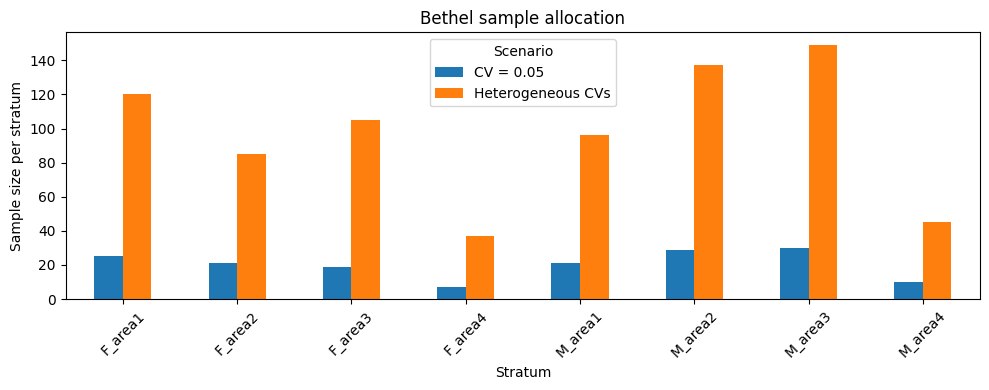

In [23]:
import matplotlib.pyplot as plt

plot_df = pd.DataFrame(
    {
        "CV = 0.05": result.set_index("strata")["adjusted_sample"],
        "Heterogeneous CVs": result_alt.set_index("strata")["adjusted_sample"],
    }
)

ax = plot_df.plot(kind="bar", figsize=(10, 4), rot=45)
ax.set_ylabel("Sample size per stratum")
ax.set_xlabel("Stratum")
ax.legend(title="Scenario")
ax.set_title("Bethel sample allocation")
plt.tight_layout()
plt.show()